In [16]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd


In [ ]:
TASKS = [
    "countdown",
    "gsm8k",
    "proofwriter",
    "hellaswag",
    "piqa",
    "arc-challenge",
    "mmlu-pro",
]

TASK_LABELS = {
    "countdown": "Countdown",
    "gsm8k": "GSM8K",
    "proofwriter": "ProofWriter",
    "hellaswag": "HellaSwag",
    "piqa": "PIQA",
    "arc-challenge": "ARC-Challenge",
    "mmlu-pro": "MMLU-Pro",
}

METRIC_NAME = "token_weighted_kl_divergence"
ANNOTATE_CELLS = True
CMAP = "viridis"
KL_COLORBAR_MIN = 1e-2

# Select three or four runs. Use either run_name for ES runs under experiments/test
# or run_path for an explicit ES/GRPO path. train_task can be left as None.

RUN_SPECS = [
    {
        "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_20260315_212803",
        "run_path": None,
        "train_task": None,
        "label": "ES (30)",
    },
    {
        "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.01_20260320_201242",
        "run_path": None,
        "train_task": None,
        "label": "ES (30) + AWD ($\\ell_1$)",
    },
        {
        # "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd5.0_20260324_114329",
        "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd10.0_20260421_151321",
        "run_path": None,
        "train_task": None,
        "label": "ES (30) + AWD ($\\ell_2$)",
    },
    {
        "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize128_msFalse_20260403_143926",
        "run_path": None,
        "train_task": None,
        "label": "ES (128)",
    },
    {
        "run_name": "Qwen2.5-3B-Instruct_countdown_seed0_popsize256_msFalse_20260427_033636",
        "run_path": None,
        "train_task": None,
        "label": "ES (256)",
    },
    {
        "run_name": None,
        "run_path": "grpo_experiments/runs/Qwen2.5-3B-Instruct_grpo_countdown_seed42",
        "train_task": None,
        "label": "GRPO",
    }
]


In [18]:
EXPERIMENT_DIR = Path("experiments/test")

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "evaluation").exists():
    if (REPO_ROOT.parent / "evaluation").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError("Run this notebook from the repo root or evaluation directory.")


def normalize_task_name(task_name):
    if task_name is None:
        return None
    task_name = str(task_name).replace("_", "-")
    aliases = {
        "arc_challenge": "arc-challenge",
        "mmlu_pro": "mmlu-pro",
    }
    return aliases.get(task_name, task_name)


def resolve_run_dir(run_spec):
    run_path = run_spec.get("run_path")
    run_name = run_spec.get("run_name")

    if run_path is not None:
        path = Path(run_path)
        return (REPO_ROOT / path).resolve() if not path.is_absolute() else path.resolve()
    if run_name:
        return (REPO_ROOT / EXPERIMENT_DIR / run_name).resolve()
    raise ValueError("Each run spec must set run_name or run_path.")


def infer_train_task(run_dir: Path, explicit_task=None):
    explicit_task = normalize_task_name(explicit_task)
    if explicit_task:
        return explicit_task

    args_path = run_dir / "args.json"
    if args_path.is_file():
        run_config = json.loads(args_path.read_text())
        config_task = normalize_task_name(run_config.get("task") or run_config.get("dataset"))
        if config_task:
            return config_task

    identifier = run_dir.name.replace("_", "-")
    for task_name in TASKS:
        if task_name in identifier:
            return task_name
    raise ValueError(f"Could not infer train task for {run_dir}; set train_task explicitly.")


def load_final_kl(run_dir: Path, task_name: str, metric_name: str):
    path = run_dir / f"{task_name}_kl.jsonl"
    if not path.is_file():
        print(f"Missing KL metrics for {task_name}: {path}")
        return np.nan, None, path

    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    if not records:
        print(f"No KL records found for {task_name}: {path}")
        return np.nan, None, path

    frame = pd.DataFrame(records).sort_values("step").reset_index(drop=True)
    final_record = frame.iloc[-1]
    if metric_name not in final_record:
        print(f"Missing metric {metric_name!r} in {path}")
        return np.nan, final_record.get("step"), path

    return float(final_record[metric_name]), int(final_record["step"]), path

rows = []
run_rows = []
for run_spec in RUN_SPECS:
    run_dir = resolve_run_dir(run_spec)
    train_task = infer_train_task(run_dir, run_spec.get("train_task"))
    label = run_spec.get("label") or train_task

    row = {}
    steps = {}
    paths = {}
    for task_name in TASKS:
        value, step, path = load_final_kl(run_dir, task_name, METRIC_NAME)
        row[task_name] = value
        steps[task_name] = step
        paths[task_name] = path

    rows.append(row)
    run_rows.append(
        {
            "label": label,
            "train_task": train_task,
            "run_dir": run_dir,
            "steps": steps,
            "paths": paths,
        }
    )

kl_table = pd.DataFrame(rows, index=[run_row["label"] for run_row in run_rows], columns=TASKS)
kl_table


,countdown,gsm8k,proofwriter,hellaswag,piqa,arc-challenge,mmlu-pro
ES (30),0.166622,0.038224,0.138634,1.117809,0.793763,0.103369,0.100124
ES (30) + AWD ($\ell_1$),0.067890,0.013914,0.061622,0.124507,0.193456,0.048979,0.072531
ES (30) + AWD ($\ell_2$),0.043994,0.010415,0.047067,0.185053,0.073822,0.029676,0.035595
ES (128),0.069243,0.015215,0.036236,0.179179,0.036052,0.032562,0.044111
ES (256),0.056671,0.010066,0.022705,0.117626,0.000753,0.024786,0.029128
GRPO,3.370662,0.037610,0.047323,0.044726,0.030616,0.029000,0.021082


In [19]:
display(kl_table)

for run_row in run_rows:
    print(f"{run_row['label']}: {run_row['run_dir']}")
    loaded_tasks = [task for task, step in run_row["steps"].items() if step is not None]
    if loaded_tasks:
        step_summary = ", ".join(f"{task}@{run_row['steps'][task]}" for task in loaded_tasks)
        print(f"  final steps: {step_summary}")


,countdown,gsm8k,proofwriter,hellaswag,piqa,arc-challenge,mmlu-pro
ES (30),0.166622,0.038224,0.138634,1.117809,0.793763,0.103369,0.100124
ES (30) + AWD ($\ell_1$),0.067890,0.013914,0.061622,0.124507,0.193456,0.048979,0.072531
ES (30) + AWD ($\ell_2$),0.043994,0.010415,0.047067,0.185053,0.073822,0.029676,0.035595
ES (128),0.069243,0.015215,0.036236,0.179179,0.036052,0.032562,0.044111
ES (256),0.056671,0.010066,0.022705,0.117626,0.000753,0.024786,0.029128
GRPO,3.370662,0.037610,0.047323,0.044726,0.030616,0.029000,0.021082


ES (30): /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_20260315_212803
  final steps: countdown@500, gsm8k@500, proofwriter@500, hellaswag@500, piqa@500, arc-challenge@500, mmlu-pro@500
ES (30) + AWD ($\ell_1$): /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.01_20260320_201242
  final steps: countdown@500, gsm8k@500, proofwriter@500, hellaswag@500, piqa@500, arc-challenge@500, mmlu-pro@500
ES (30) + AWD ($\ell_2$): /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd10.0_20260421_151321
  final steps: countdown@500, gsm8k@500, proofwriter@500, hellaswag@500, piqa@500, arc-challenge@500, mmlu-pro@500
ES (128): /home/kajetan/es_finetuning/experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize128_msFalse_20260403_143926
  final steps: countdown@500, gsm8k@500, proofwriter@500, hellaswag@500, piqa@500, arc-challenge@500, mml

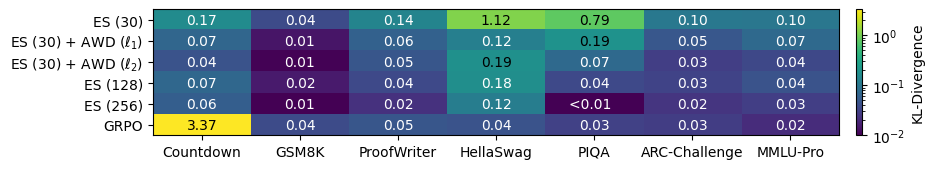

In [20]:
values = kl_table.to_numpy(dtype=float)
finite_positive_values = values[np.isfinite(values) & (values > 0)]

if finite_positive_values.size:
    log_vmax = finite_positive_values.max()
    if log_vmax <= KL_COLORBAR_MIN:
        log_vmax = KL_COLORBAR_MIN * 10
    log_norm = LogNorm(vmin=KL_COLORBAR_MIN, vmax=log_vmax, clip=True)
    plot_values = values.copy()
    plot_values[np.isfinite(plot_values) & (plot_values < KL_COLORBAR_MIN)] = KL_COLORBAR_MIN
else:
    log_norm = None
    plot_values = values

masked_values = np.ma.masked_invalid(plot_values)

cmap = plt.get_cmap(CMAP).copy()
cmap.set_bad(color="#eeeeee")

fig, ax = plt.subplots(figsize=(10, 1.8))
image = ax.imshow(masked_values, cmap=cmap, aspect="auto", norm=log_norm)

ax.set_xticks(np.arange(len(TASKS)))
ax.set_xticklabels([TASK_LABELS[task] for task in TASKS])
ax.set_yticks(np.arange(len(kl_table.index)))
ax.set_yticklabels(kl_table.index)
# ax.set_xlabel("Evaluation task")
# ax.set_ylabel("Train task")

if ANNOTATE_CELLS:
    for row_idx in range(values.shape[0]):
        for col_idx in range(values.shape[1]):
            value = values[row_idx, col_idx]
            if not np.isfinite(value):
                text = "missing"
                color = "#555555"
            else:
                text = f"{value:.2f}" if value >= KL_COLORBAR_MIN else f"<{KL_COLORBAR_MIN:.2f}  "
                color = "white" if log_norm is not None and value > 0 and log_norm(value) < 0.5 else "black"
            ax.text(col_idx, row_idx, text, ha="center", va="center", color=color, fontsize=10)

ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("KL-Divergence")
fig.tight_layout()
plt.savefig("kl_divergence_comparison.pdf", bbox_inches="tight")
plt.show()
